# Reading the data

This is the original dta I used for the MultiCAM paper.

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from multicam_bolshoi.mah import get_mah
mah_data = get_mah('../data/processed/bolshoi_m12', cutoff_missing=0.05, cutoff_particle=0.05)


# extract mah of all haloes 
ma = mah_data['ma_peak']
ma.shape # the first dimension is the number of haloes, the second is the number of snapshots.

scales = mah_data['scales']
scales.shape


cat = mah_data['cat'] # astropy table with present-day halo properties
cvir = cat['cvir']
xoff = cat['x0']
t_over_u = cat['t/|u|']
spin = cat['spin_bullock']
c_to_a = cat['c_to_a']

cvir.shape, spin.shape # 1 dimensional quantities, one per halo

((10000,), (10000,))

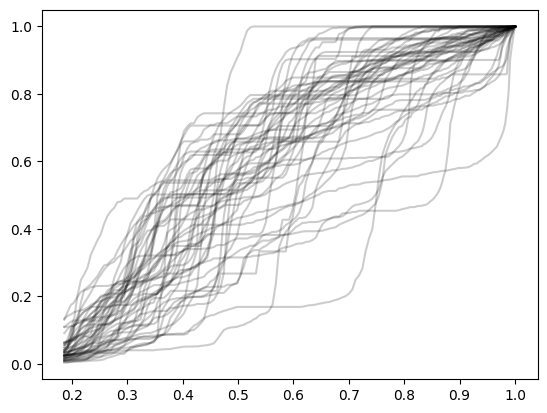

In [62]:
# MAH examples 
for _ in range(50):
    indx= np.random.randint(len(ma))
    plt.plot(scales, ma[indx], color='k', alpha=0.2)

(array([0.000e+00, 4.700e+01, 7.900e+01, 1.370e+02, 2.170e+02, 3.050e+02,
        3.960e+02, 5.480e+02, 7.530e+02, 8.640e+02, 1.004e+03, 1.093e+03,
        9.630e+02, 9.650e+02, 7.620e+02, 5.860e+02, 4.090e+02, 2.930e+02,
        2.090e+02, 1.030e+02, 8.300e+01, 3.600e+01, 2.600e+01, 2.600e+01,
        1.300e+01, 1.200e+01, 1.200e+01, 9.000e+00, 5.000e+00, 8.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00]),
 array([ 0.        ,  0.78431373,  1.56862745,  2.35294118,  3.1372549 ,
         3.92156863,  4.70588235,  5.49019608,  6.2745098 ,  7.05882353,
         7.84313725,  8.62745098,  9.41176471, 10.19607843, 10.98039216,
        11.76470588, 12.54901961, 13.33333333, 14.11764706, 14.90196078,
        15.68627451, 16.47058824, 17.25490196, 18.03921569, 18.82352941,


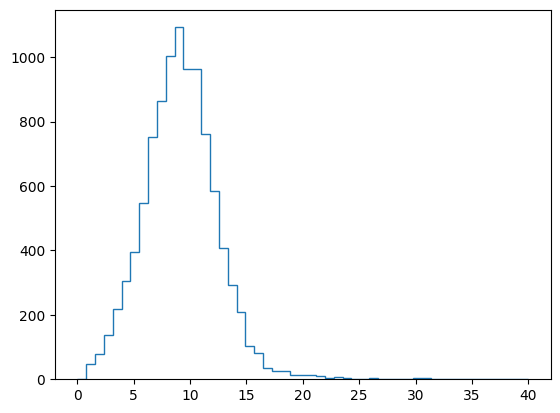

In [63]:
# concentration histogram 
plt.hist(cvir, bins=51, histtype='step', range=(0, 40))

# Algorithms

The first algorithm here `multicam` is the implementation using the sklearn quantile transformers. 
Importantly, it is modified from the original version in the paper in that I fixed the issue where the 
prediction output depends on the distribution of the input test points (i.e., the prediction will be different
if done one test point at a time, rather than using them all at once).
For simplicity, there are no bells and whistles related to handling repeat values using ranks.
The algorithm can be summarized at a high level as:

1. Transform training data `x_train`, `y_train` (marginally) to gaussian distributions. 
2. Fit a linear regression model on these gaussianized training data sets. 
3. Gaussianize `x_test` **using the same QT** that was used to gaussianize `x_train`.
4. Do a prediction using the trained linear regresion model on the gaussianized `x_test`.
5. This prediction `y_not_gauss` does not necessarily match a Gaussian distribution. We create 
an additional QT that gaussianizes the prediction of the LR model on the gaussianized `x_train`. 
We use this new QT to gaussianize `y_not_gauss` resulting in `y_gauss`.
6. We use the QT that gaussianized `y_train` to transform `y_gauss` and bring it back to $y$ space.

Note that in several steps it is crucial to use the QT fit to the training data so that the output 
does not depend on how many test points are used at prediction time.

The second implementation `new_multicam` is my attempt at an implementation that does not utilize the
sklearn quantile transformers. It depends on four functions `qt_uniform`, `qt_gauss`, `qt_gauss_base`, and `qt_inverse_gauss_base`.
For example `qt_gauss_base` is designed to mimic a QT that transforms an input to a gaussian distribution, but that was first fit 
to a different collection of points (e.g. gaussianizing `x_test` based on a QT fit to `x_train`). This function and the inverse 
use simple linear interpolation to accomplish this.

In [9]:
from sklearn.preprocessing import QuantileTransformer
from sklearn import linear_model


def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal", subsample=None)
    qt.fit(x)
    return qt.transform(x), qt


def multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss, qtx = _gauss_transform(x_train)
    yt_gauss, qty = _gauss_transform(y_train)
    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qtx.transform(x)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    _, qtp = _gauss_transform(y_pred_train)
    y_gauss = qtp.transform(y_not_gauss)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qty.inverse_transform(y_gauss)
    return y_pred, y_gauss, y_not_gauss, x_gauss

In [10]:
from scipy.stats import norm, rankdata

def qt_uniform(x, axis: int = 0, method="ordinal"):  # default in rankdata = 'average'
    """Transform array to a uniform distribution based on ranks."""
    ranks = rankdata(x, axis=axis, method=method)
    return ranks / (ranks.shape[axis] + 1)  # excludes 0 and 1


def qt_gauss(x, axis: int = 0, method="ordinal"):
    """Transform array to a Gaussian distribution based on ranks."""
    u = qt_uniform(x, axis=axis, method=method)
    return norm.ppf(u)


def qt_gauss_base(x, x_base):
    """Gaussinize input based on another dataset."""
    # always assume second dimension is n_features.
    assert x.ndim == 2 and x_base.ndim == 2
    assert x.shape[1] == x_base.shape[1]
    n_features = x.shape[1]
    x_gauss = np.zeros_like(x) * np.nan
    for jj in range(n_features):
        x_jj = x[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_gauss[:, jj] = np.interp(x_jj, xb_jj, xb_gauss_jj)
    return x_gauss


def qt_inverse_gauss_base(x_gauss, x_base):
    assert x_gauss.ndim == 2 and x_base.ndim == 2
    assert x_gauss.shape[1] == x_base.shape[1]
    n_features = x_gauss.shape[1]
    x_out = np.zeros_like(x_gauss) * np.nan
    for jj in range(n_features):
        xg_jj = x_gauss[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_out[:, jj] = np.interp(xg_jj, xb_gauss_jj, xb_jj)
    return x_out

def new_multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss = qt_gauss(x_train, axis=0)
    yt_gauss = qt_gauss(y_train, axis=0)

    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qt_gauss_base(x, x_train)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    y_gauss = qt_gauss_base(y_not_gauss, y_pred_train)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qt_inverse_gauss_base(y_gauss, y_train) 
    return y_pred, y_gauss, y_not_gauss, x_gauss


# Results

In what follows I'm trying to demonstrate the issue with the new implementation. The first two sections below use a single feature of the MAH for prediction. 
You can see that the output distribution of the prediction from the old and new multicam are the same, no issues here. The spearman correlation is also the same.

However, there are issues that I don't understand when we get to the multivariable feature case. You can see significant differences between the prediction distribution for each model. 
In the full MAH case ('all features') the spearman correlation coefficient is significantly larger for the original multicam approach. 
You can see there is a difference in the correlation coefficient when only using two features (although not as big). 

I suspected it has something to do with the fact that in the MAH there is a significant number of haloes where the normalized peak mass `m(a) = 1` as you get closer to present day. But it only happens in the multi-feature case, so I feel like there is something complicated going on.

I'm making histograms of intermediate steps in the model. First I'm showing histograms of the gaussianization of each feature (`xg`), I'm also showing histograms of the raw prediction from the linear regression model (`yng`), and after this is Gaussianized (`yg`). You can see that in some cases thare differences in these histograms between the old and new multicam and that migth be an issue.

In [11]:
from multicam.train import _get_tt_indices

n_haloes = len(cat)
train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

## Only one feature (low repeats)

In [12]:
ma_train = ma[train_idx]
ma_test = ma[test_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

an_train = ma_train[:, 41, None]
an_test = ma_test[:, 41, None]

an_train.shape, cvir_train.shape

((7500, 1), (7500, 1))

In [13]:
# number of repeats
np.sum(ma[:, 41] == 1.)

np.int64(2)

In [14]:
yp1, yg1, yng1, xg1 = multicam(an_test, an_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(an_test, an_train, cvir_train)

In [15]:
xg2.shape

(2500, 1)

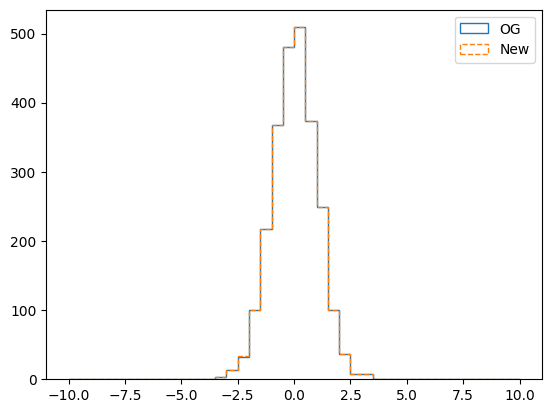

In [16]:
bins = np.linspace(-10, 10, 41)
_, bins, _ = plt.hist(xg1, bins=bins, histtype='step', label='OG')
plt.hist(xg2, bins=bins, histtype='step', ls='--', label='New');
plt.legend()

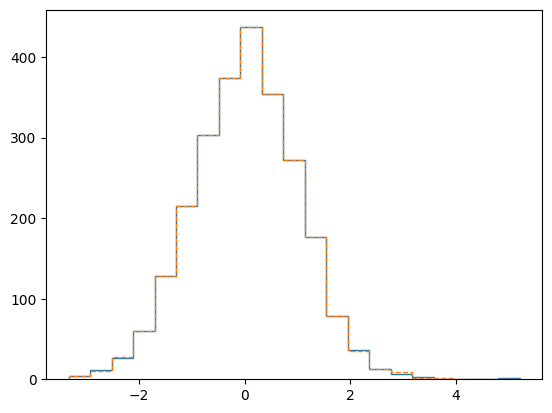

In [17]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step')
plt.hist(yg2, bins=bins, histtype='step', ls='--');

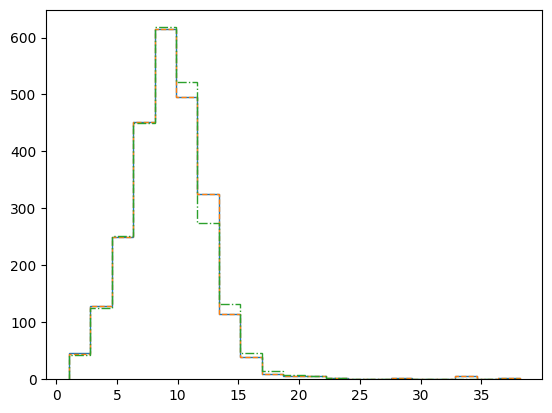

In [18]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [19]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.6753842684488305), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.6753842684488305), pvalue=np.float64(0.0)))

## Only 1 feature (many repeats)

In [20]:
ma_train = ma[train_idx]
ma_test = ma[test_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

an_train = ma_train[:, 130, None]
an_test = ma_test[:, 130, None]

an_train.shape, cvir_train.shape

((7500, 1), (7500, 1))

In [21]:
# number of repeats
np.sum(ma[:, 130] == 1.)

np.int64(2229)

In [22]:
yp1, yg1, yng1, xg1 = multicam(an_test, an_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(an_test, an_train, cvir_train)

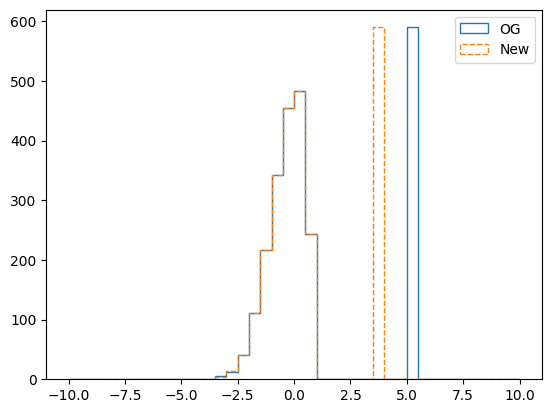

In [23]:
bins = np.linspace(-10, 10, 41)
_, bins, _ = plt.hist(xg1, bins=bins, histtype='step', label='OG')
plt.hist(xg2, bins=bins, histtype='step', ls='--', label='New');
plt.legend()

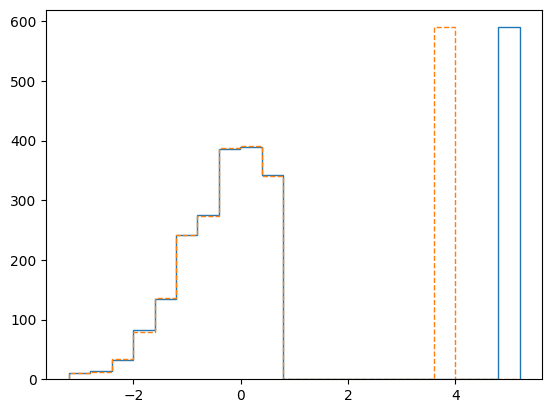

In [24]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step')
plt.hist(yg2, bins=bins, histtype='step', ls='--');

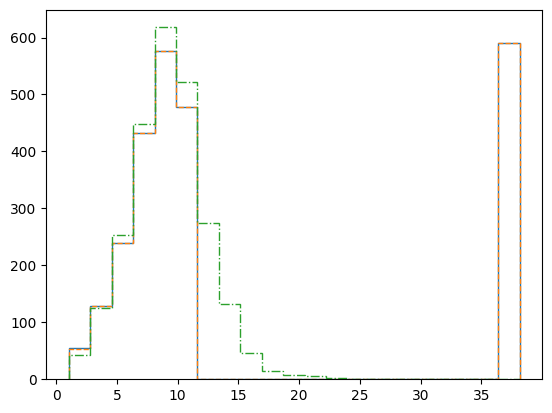

In [25]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [26]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.15959222067391104), pvalue=np.float64(9.978826427623792e-16)),
 SignificanceResult(statistic=np.float64(0.15959222067391104), pvalue=np.float64(9.978826427623792e-16)))

## All features

In [27]:
ma_train = ma[train_idx][:, :]
ma_test = ma[test_idx][:, :]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)


In [28]:
yp1, yg1, yng1, xg1 = multicam(ma_test, ma_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(ma_test, ma_train, cvir_train)

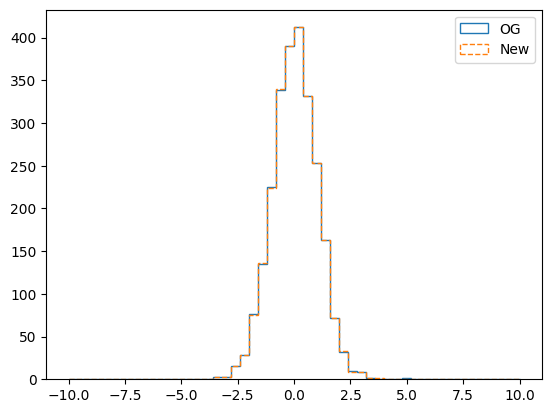

In [29]:
idx = 41
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='New');
plt.legend()

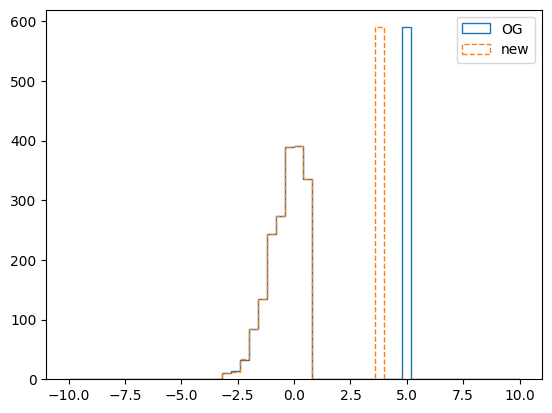

In [30]:
idx = 130
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='new');
plt.legend()

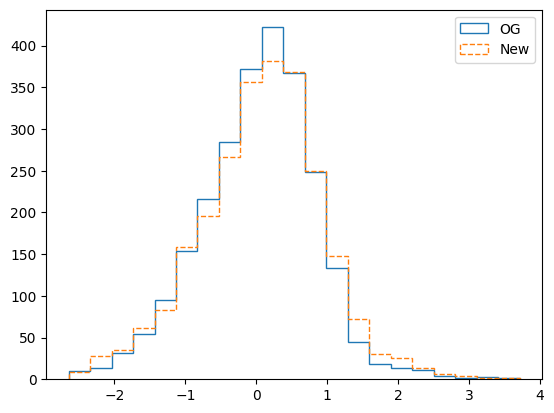

In [31]:
_, bins, _ = plt.hist(yng1, bins=21, histtype='step', label="OG")
plt.hist(yng2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

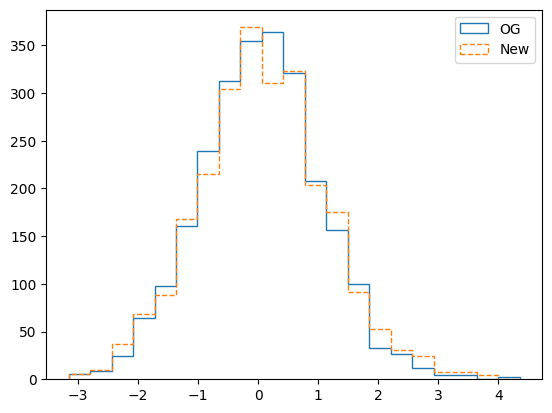

In [32]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step', label="OG")
plt.hist(yg2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

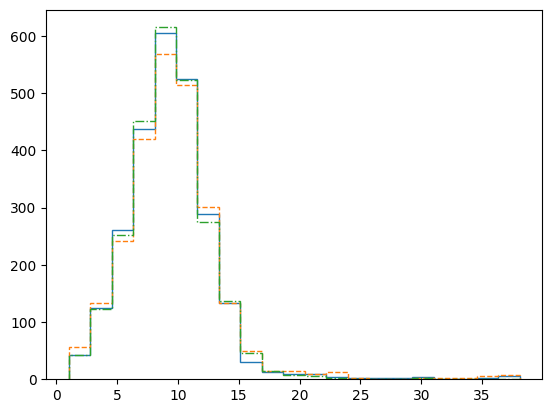

In [33]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [34]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.7758868864028721), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.718743493934944), pvalue=np.float64(0.0)))

## Two features (low and high repeats)

In [52]:
ma_train = ma[train_idx][:, [40, 140]]
ma_test = ma[test_idx][:, [40, 140]]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

ma_train.shape

(7500, 2)

In [53]:
yp1, yg1, yng1, xg1 = multicam(ma_test, ma_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(ma_test, ma_train, cvir_train)

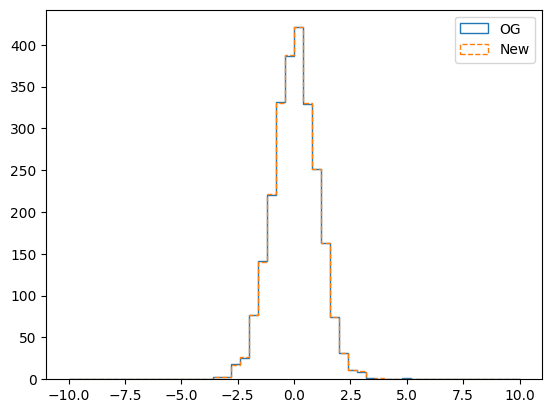

In [54]:
idx = 0
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='New');
plt.legend()

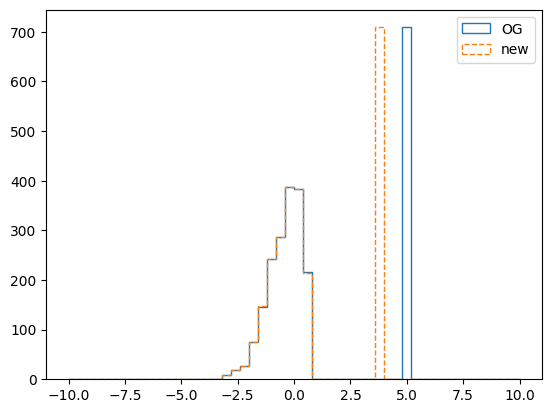

In [55]:
idx = 1
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='new');
plt.legend()

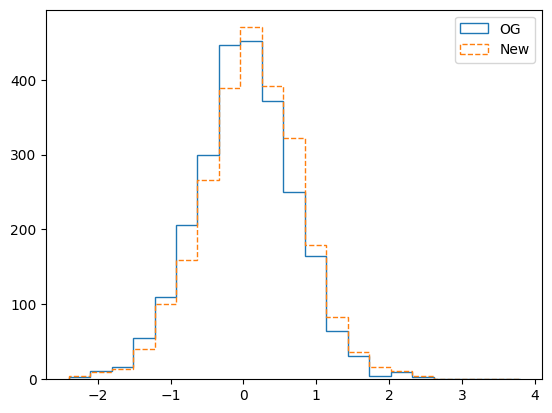

In [56]:
_, bins, _ = plt.hist(yng1, bins=21, histtype='step', label="OG")
plt.hist(yng2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

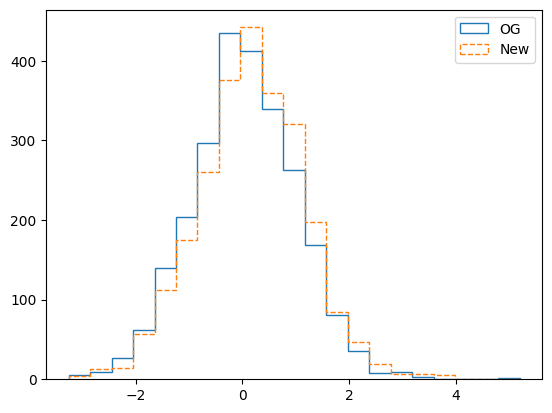

In [57]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step', label="OG")
plt.hist(yg2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

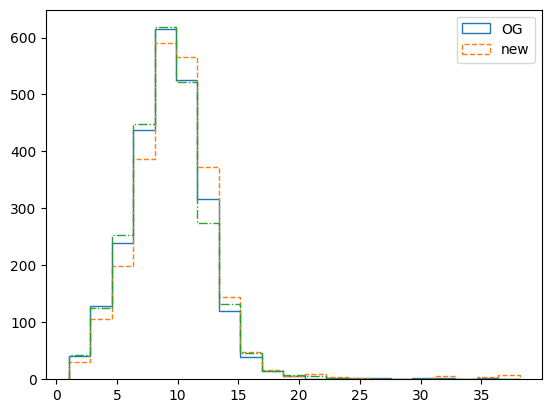

In [60]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step', label='OG')
plt.hist(yp2, bins=bins, histtype='step', ls='--', label='new');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');
plt.legend()

In [59]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.6851660539501205), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.6681859100489542), pvalue=np.float64(4e-323)))

## Two features (low repeats)

In [64]:
ma_train = ma[train_idx][:, [40, 60]]
ma_test = ma[test_idx][:, [40, 60]]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

ma_train.shape

(7500, 2)

In [65]:
yp1, yg1, yng1, xg1 = multicam(ma_test, ma_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(ma_test, ma_train, cvir_train)

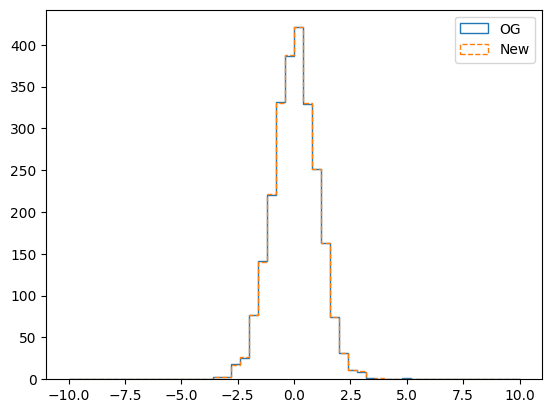

In [66]:
idx = 0
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='New');
plt.legend()

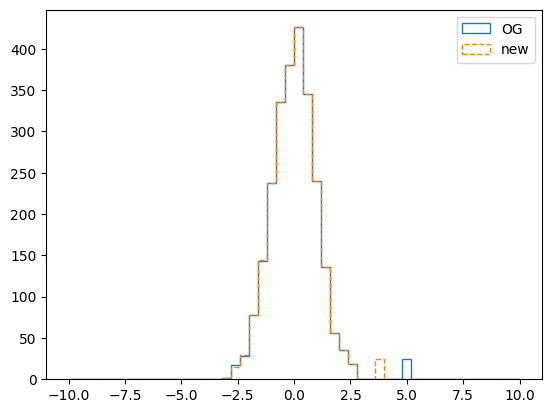

In [67]:
idx = 1
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='new');
plt.legend()

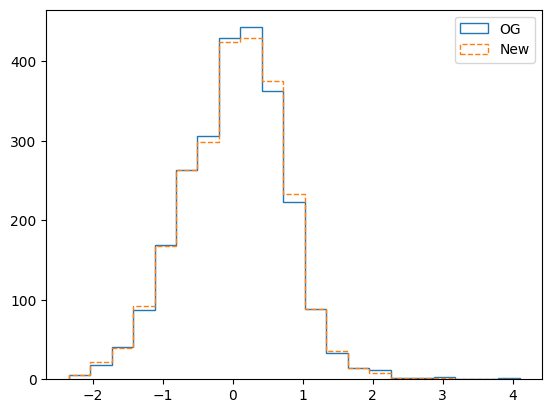

In [68]:
_, bins, _ = plt.hist(yng1, bins=21, histtype='step', label="OG")
plt.hist(yng2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

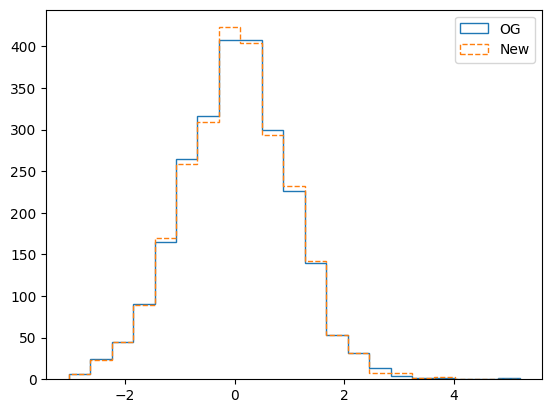

In [69]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step', label="OG")
plt.hist(yg2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

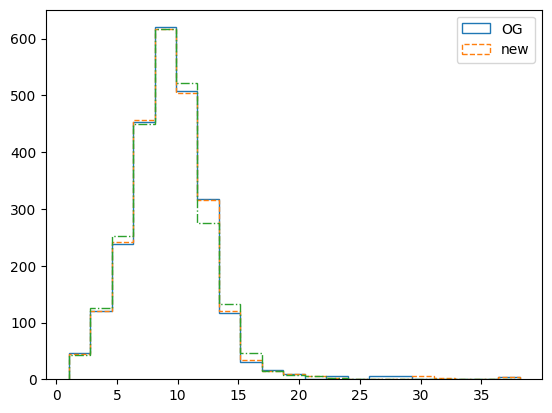

In [70]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step', label='OG')
plt.hist(yp2, bins=bins, histtype='step', ls='--', label='new');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');
plt.legend()

In [71]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.7108562444334836), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7114095986684891), pvalue=np.float64(0.0)))